# Electric Vehicle Market Analysis in India (2014–2024)

## Environment Setup & Data Hygiene
Initialisation of the core data analysis runtime, ingestion of raw regional registration records, and execution of a structural audit to verify completeness, duplicate-free integrity, and baseline schema quality.

In [63]:
# Import foundational libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

# Suppress harmless warnings for clean notebook presentation
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [64]:
# Load the dataset
file_path = 'ev_sales_india.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")

    # Display the first 5 rows to understand the structure
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please upload it to your Colab session.")

Dataset loaded successfully!


,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


### Structural Audit
We will inspect the dimensionality, data types, missing values, and duplicate records to ensure absolute data hygiene before proceeding to transformations.

In [65]:
# 1. Dimensionality
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 2. General Information & Datatypes
print("--- Data Information ---")
df.info()
print("\n")

# 3. Missing Values Check
print("--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")
print("\n")

# 4. Duplicate Rows Check
duplicates = df.duplicated().sum()
print(f"--- Duplicates ---")
print(f"Total duplicate rows: {duplicates}")

Dataset Shape: 96845 rows, 8 columns

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


--- Missing Values ---
No missing values found!


--- Duplicates ---
Total duplicate rows: 0


## Data Transformation & Memory Optimisation
Schema casting and datatype optimisation - parsing temporal fields to `datetime64`, numeric metrics to efficient integer representations (`int32`), and low-cardinality strings to `category` datatypes to significantly minimise memory footprint and accelerate downstream aggregations.

In [66]:
# Measure baseline memory footprint
initial_memory = df.memory_usage(deep=True).sum() / (1024 ** 2)

# Convert temporal attributes
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Year'].astype('int32')

# Convert numeric metrics
df['EV_Sales_Quantity'] = df['EV_Sales_Quantity'].astype('int32')

# Convert categorical columns to optimize memory and grouping speed
categorical_columns = ['Month_Name', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']
df[categorical_columns] = df[categorical_columns].astype('category')

# Measure optimised memory footprint
final_memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
memory_reduction = ((initial_memory - final_memory) / initial_memory) * 100

In [67]:
# Output memory optimisation results
print(f"Initial Memory Usage : {initial_memory:.2f} MB")
print(f"Optimised Memory Usage: {final_memory:.2f} MB")
print(f"Total Memory Reduction: {memory_reduction:.2f}%\n")

# Display updated schema
print("--- Optimised Dataset Schema ---")
df.info()

Initial Memory Usage : 33.50 MB
Optimised Memory Usage: 1.95 MB
Total Memory Reduction: 94.17%

--- Optimised Dataset Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               96845 non-null  int32         
 1   Month_Name         96845 non-null  category      
 2   Date               96845 non-null  datetime64[ns]
 3   State              96845 non-null  category      
 4   Vehicle_Class      96845 non-null  category      
 5   Vehicle_Category   96845 non-null  category      
 6   Vehicle_Type       96845 non-null  category      
 7   EV_Sales_Quantity  96845 non-null  int32         
dtypes: category(5), datetime64[ns](1), int32(2)
memory usage: 1.9 MB


## Feature Engineering & Macro Aggregations
Creation of temporal metrics, usage-based categorisation, and the compilation of master summary tables for national and state-level insights.

In [68]:
# Extract temporal components
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Year_Month'] = df['Date'].dt.to_period('M')

# Define and apply a high-level usage segment mapping
def classify_usage(v_type):
    type_str = str(v_type)
    if 'Personal' in type_str:
        return 'Personal'
    elif 'Goods' in type_str:
        return 'Freight / Goods'
    elif 'Shared' in type_str or 'Bus' in type_str:
        return 'Public / Shared'
    else:
        return 'Specialised / Others'

df['Usage_Segment'] = df['Vehicle_Type'].apply(classify_usage).astype('category')

# Display updated structural sample
display(df[['Date', 'Year_Month', 'Quarter', 'Vehicle_Type', 'Usage_Segment']].sample(6))

,Date,Year_Month,Quarter,Vehicle_Type,Usage_Segment
4130,2019-01-01,2019-01,1,Others,Specialised / Others
24365,2022-03-01,2022-03,1,3W_Personal,Personal
44469,2018-06-01,2018-06,2,2W_Personal,Personal
8366,2024-01-01,2024-01,1,2W_Personal,Personal
91750,2017-12-01,2017-12,4,Others,Specialised / Others
82969,2016-11-01,2016-11,4,3W_Shared,Public / Shared


In [69]:
# 1. Yearly National Performance Table
yearly_sales = df.groupby('Year', as_index=False)['EV_Sales_Quantity'].sum()
yearly_sales['YoY_Growth_%'] = yearly_sales['EV_Sales_Quantity'].pct_change() * 100

# 2. Monthly National Trend & Rolling Average Table
monthly_national = df.groupby('Date', as_index=False)['EV_Sales_Quantity'].sum()
monthly_national['Rolling_3M'] = monthly_national['EV_Sales_Quantity'].rolling(window=3).mean()

# 3. State-Level Pareto Summary Table
state_summary = df.groupby('State', observed=False, as_index=False)['EV_Sales_Quantity'].sum()
state_summary = state_summary.sort_values(by='EV_Sales_Quantity', ascending=False)
state_summary['Market_Share_%'] = (state_summary['EV_Sales_Quantity'] / state_summary['EV_Sales_Quantity'].sum()) * 100
state_summary['Cumulative_Share_%'] = state_summary['Market_Share_%'].cumsum()

print("Master aggregations successfully compiled!")
display(yearly_sales.tail(6))

Master aggregations successfully compiled!


,Year,EV_Sales_Quantity,YoY_Growth_%
5,2019,166819,28.072075
6,2020,124684,-25.257914
7,2021,331498,165.870521
8,2022,1024723,209.118909
9,2023,1525179,48.838174
10,2024,143182,-90.612118


## Exploratory Data Analysis & Visualisations

Comprehensive visual exploration across 20 analytical charts evaluating national growth trajectories, vehicle segment dynamics, regional penetration, and commercial fleet logistics.


### Part 1: National Adoption & Macro Trends
Understanding the aggregate volume of EV adoption, annual growth momentum, seasonal peaks, and smoothed long-term trends across the entire Indian market.

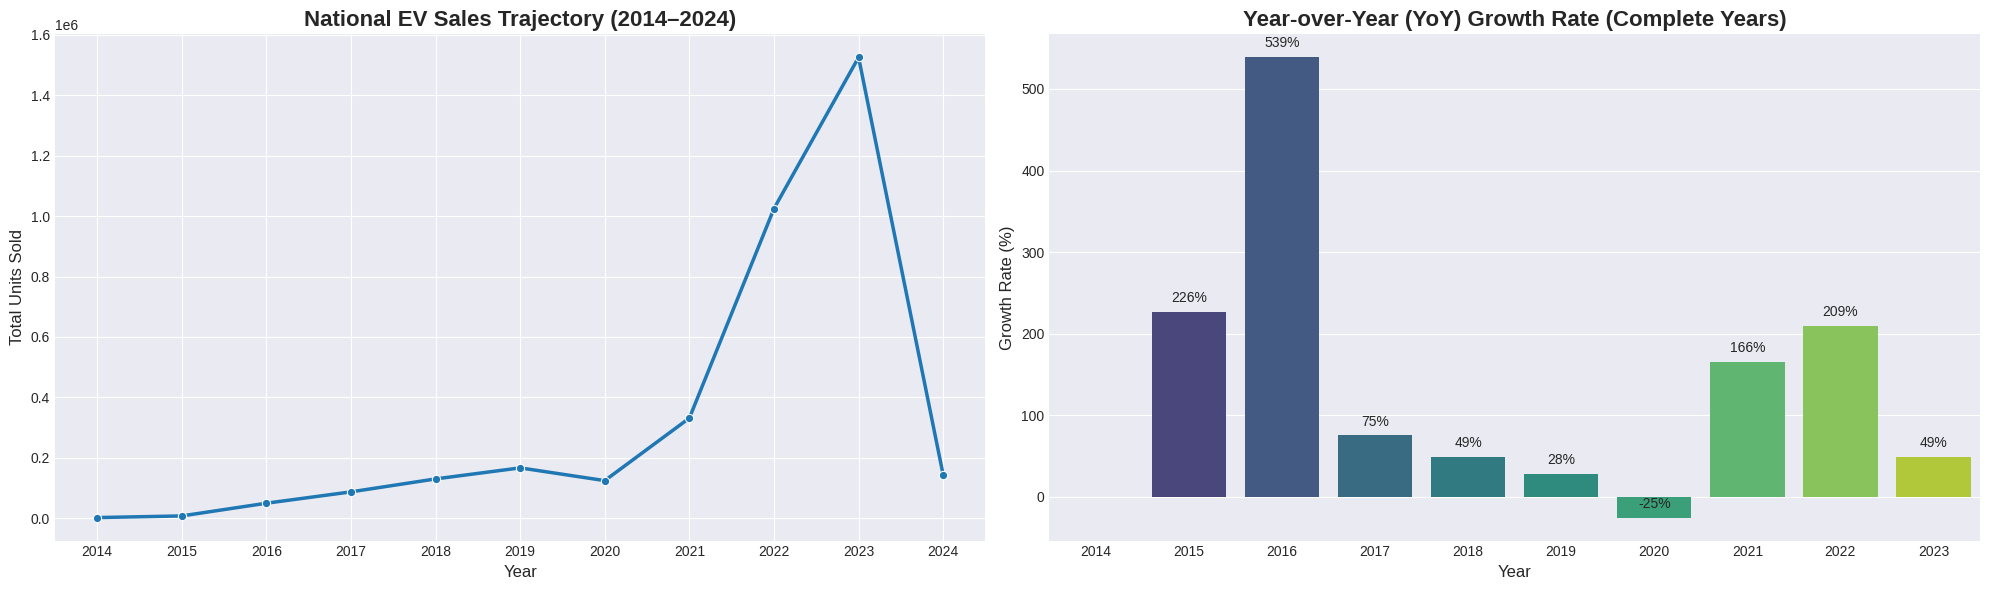

In [70]:
# Create a 1x2 subplot grid for national trajectory and YoY growth
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# 1: National Sales Trajectory
sns.lineplot(
    data=yearly_sales,
    x='Year',
    y='EV_Sales_Quantity',
    marker='o',
    linewidth=2.5,
    ax=ax[0],
    color='#1f77b4'
)
ax[0].set_title('National EV Sales Trajectory (2014–2024)')
ax[0].set_ylabel('Total Units Sold')
ax[0].set_xticks(yearly_sales['Year'])

# 2: YoY Growth Rate
# Note: Excluding 2024 as it only contains partial (January) data, which skews YoY calculations.
yearly_sales_complete = yearly_sales[yearly_sales['Year'] < 2024].copy()
sns.barplot(
    data=yearly_sales_complete,
    x='Year',
    y='YoY_Growth_%',
    palette='viridis',
    ax=ax[1]
)
ax[1].set_title('Year-over-Year (YoY) Growth Rate (Complete Years)')
ax[1].set_ylabel('Growth Rate (%)')

# Add percentage labels on top of the bars
for p in ax[1].patches:
    if not np.isnan(p.get_height()):
        ax[1].annotate(f"{p.get_height():.0f}%",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

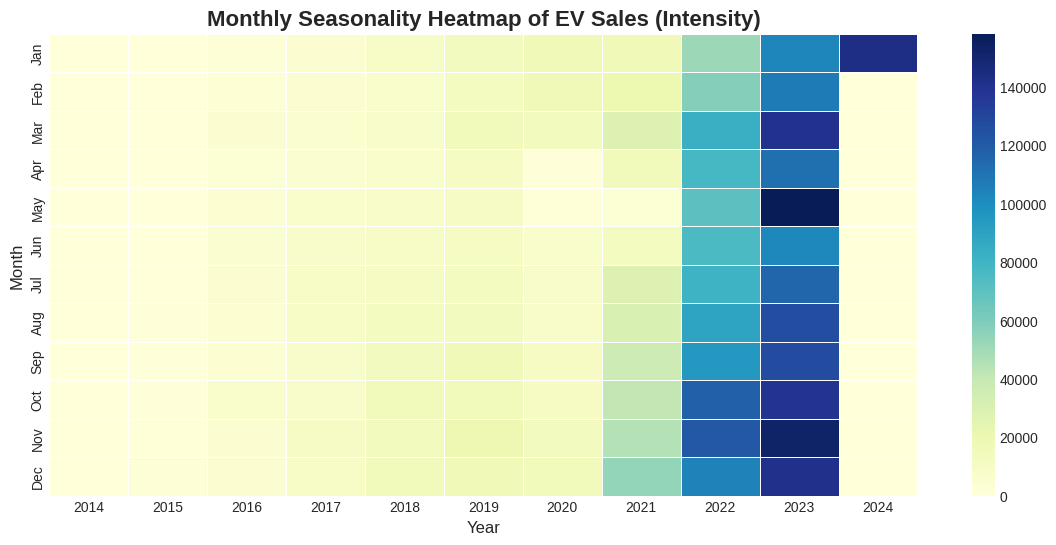

In [71]:
# 3: Monthly Seasonality Heatmap
# Pivot the data to create a matrix of Year vs Month
monthly_seasonality = df.pivot_table(
    index='Month_Name',
    columns='Year',
    values='EV_Sales_Quantity',
    aggfunc='sum',
    observed=False
)

# Reorder the index chronologically and format strings
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_seasonality = monthly_seasonality.reindex(month_order)
monthly_seasonality.index = monthly_seasonality.index.str.title()

plt.figure(figsize=(14, 6))
sns.heatmap(monthly_seasonality, cmap='YlGnBu', linewidths=0.5, annot=False)
plt.title('Monthly Seasonality Heatmap of EV Sales (Intensity)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

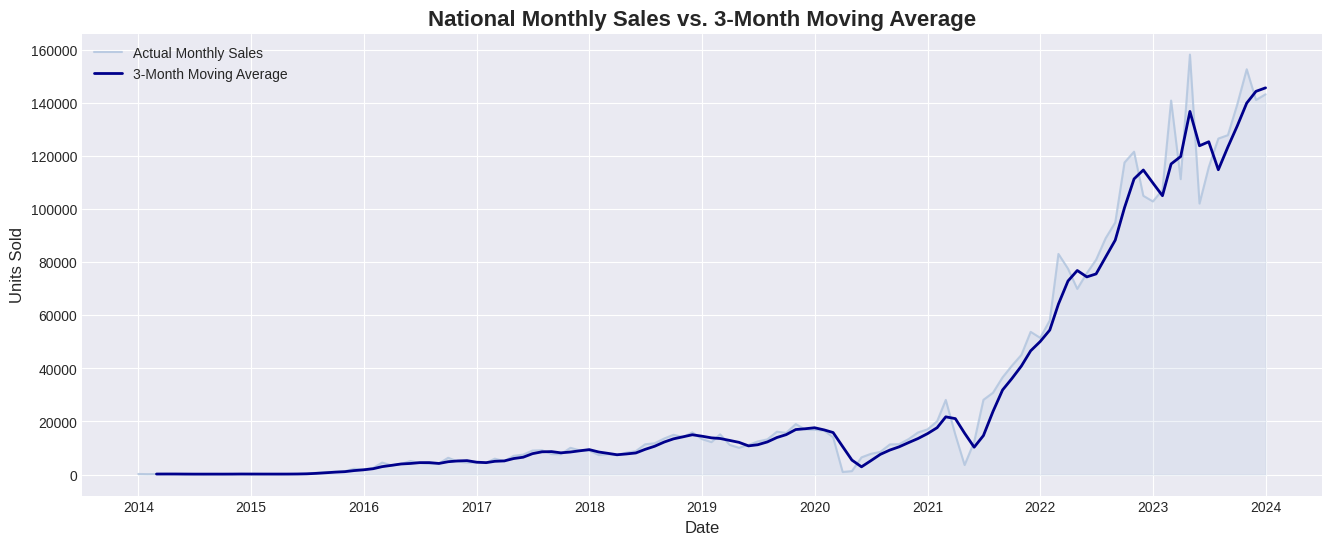

In [72]:
# 4: 3-Month Moving Average vs Actual Sales
plt.figure(figsize=(16, 6))

# Plot underlying actual sales with lower opacity
sns.lineplot(
    data=monthly_national,
    x='Date',
    y='EV_Sales_Quantity',
    label='Actual Monthly Sales',
    color='lightsteelblue',
    alpha=0.8
)

# Plot smoothed 3-month moving average
sns.lineplot(
    data=monthly_national,
    x='Date',
    y='Rolling_3M',
    label='3-Month Moving Average',
    color='darkblue',
    linewidth=2
)

# Shade the area under the actual sales curve for visual weight
plt.fill_between(
    monthly_national['Date'],
    monthly_national['EV_Sales_Quantity'],
    color='lightsteelblue',
    alpha=0.2
)

plt.title('National Monthly Sales vs. 3-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

### Part 2: Vehicle Category & Segment Dynamics
Analysing the distribution of EV sales across major vehicle categories, tracking market dominance evolution, isolating top-performing vehicle classes, and comparing commercial versus personal mobility trends.

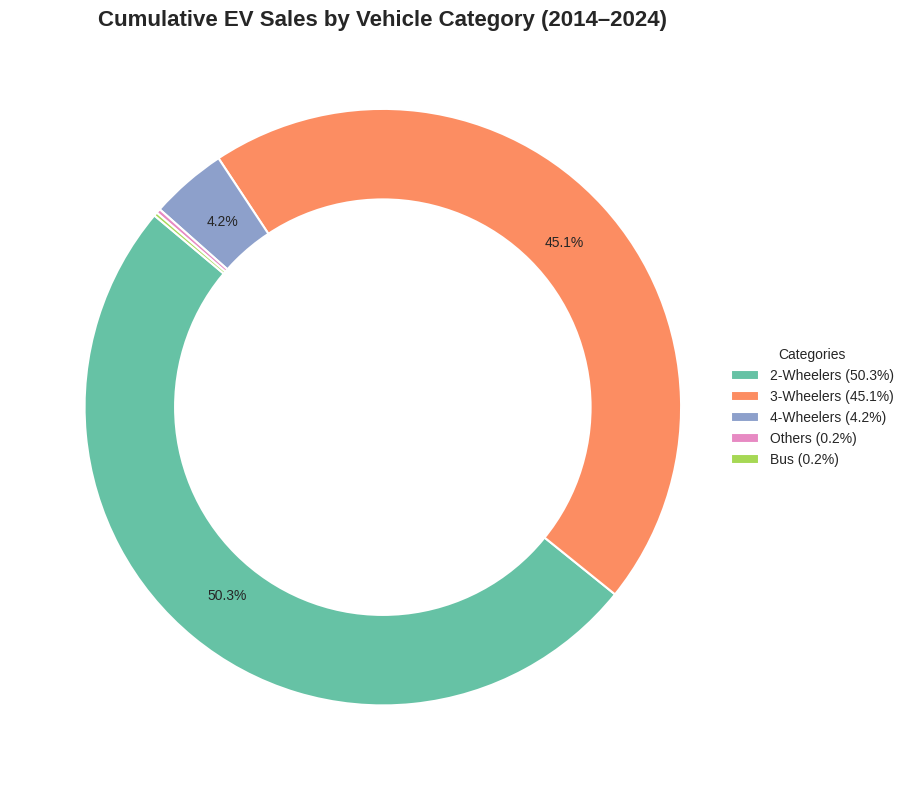

In [73]:
# 5: Market Share Donut Chart
# Aggregate total sales by overarching vehicle category
cat_sales = df.groupby('Vehicle_Category', observed=False)['EV_Sales_Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    cat_sales,
    labels=None, # Removed direct labels to prevent overlapping
    autopct='%1.1f%%',
    pctdistance=0.82,
    startangle=140,
    colors=sns.color_palette("Set2"),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Hide percentage text for slices smaller than 2% to prevent text overlap
for i, autotext in enumerate(autotexts):
    if (cat_sales.iloc[i] / cat_sales.sum()) < 0.02:
        autotext.set_text('')

# Draw central circle to create donut aesthetic
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Create a clean side-legend with percentages included
legend_labels = [f'{idx} ({val/cat_sales.sum()*100:.1f}%)' for idx, val in zip(cat_sales.index, cat_sales.values)]
plt.legend(wedges, legend_labels, title="Categories", loc="center left", bbox_to_anchor=(0.95, 0.5))

plt.title('Cumulative EV Sales by Vehicle Category (2014–2024)')
plt.tight_layout()
plt.show()

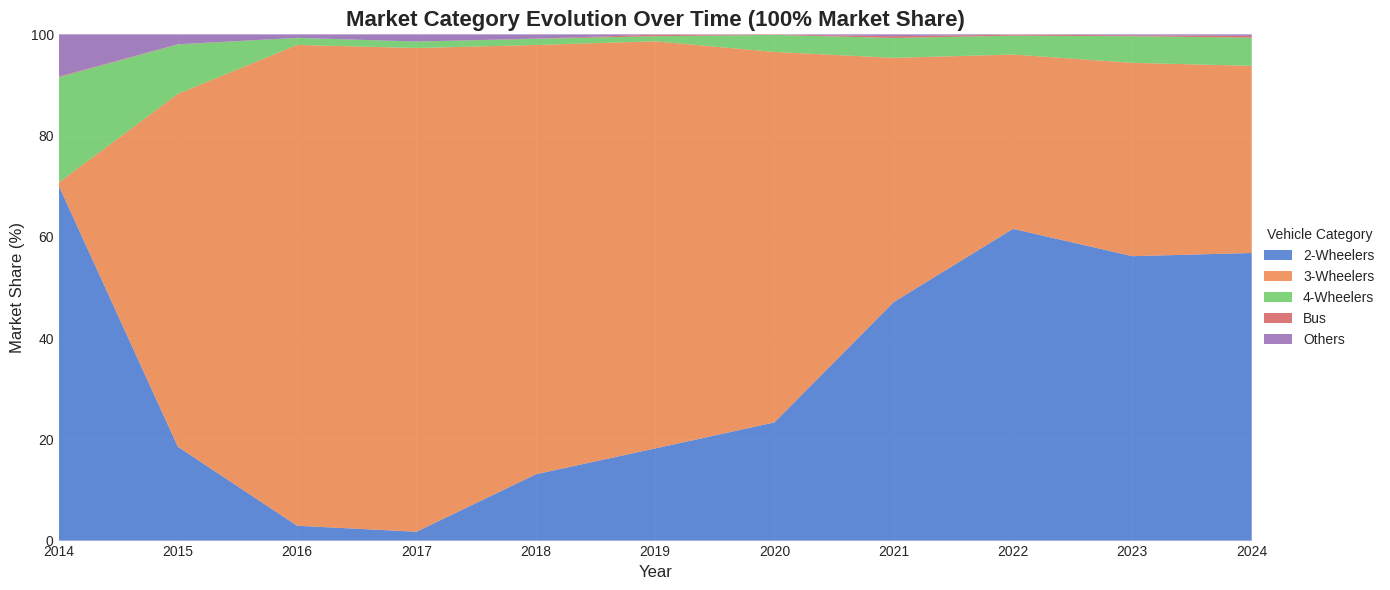

In [74]:
# 6: Stacked Area Chart
# Create pivot table for yearly category sales and calculate percentage shares
cat_year = df.pivot_table(
    index='Year',
    columns='Vehicle_Category',
    values='EV_Sales_Quantity',
    aggfunc='sum',
    observed=False
).fillna(0)

cat_year_pct = cat_year.div(cat_year.sum(axis=1), axis=0) * 100

# Render 100% Stacked Area Chart
plt.figure(figsize=(14, 6))
plt.stackplot(
    cat_year_pct.index,
    cat_year_pct.T,
    labels=cat_year_pct.columns,
    alpha=0.85,
    cmap='tab10'
)

plt.title('Market Category Evolution Over Time (100% Market Share)')
plt.ylabel('Market Share (%)')
plt.xlabel('Year')
plt.xticks(cat_year_pct.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Vehicle Category")
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()

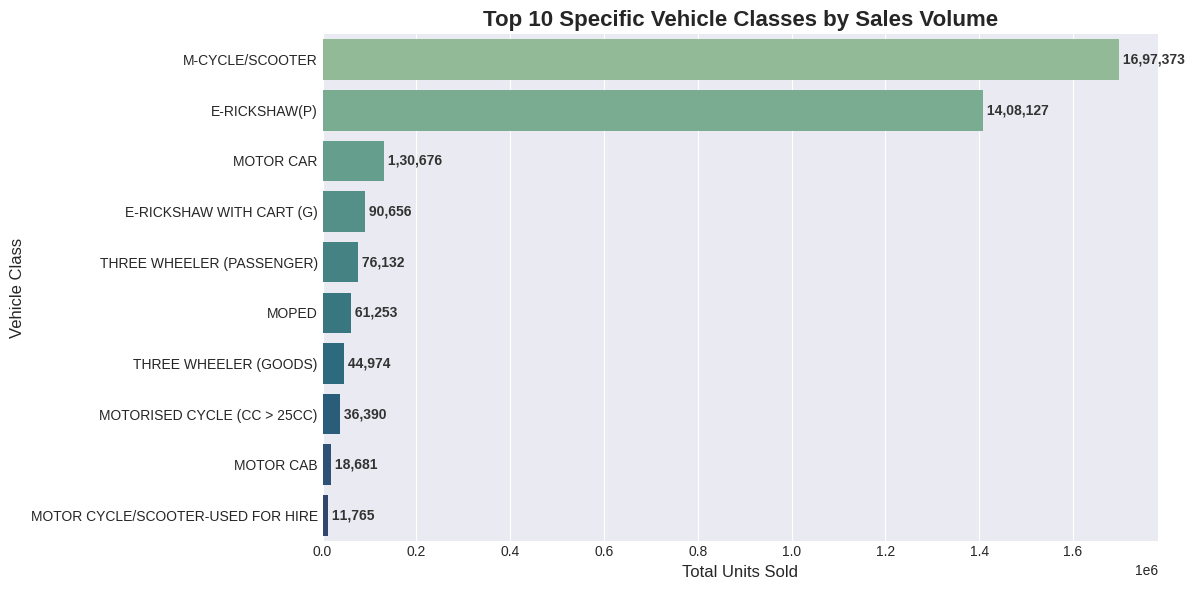

In [75]:
# 7: Top 10 Vehicle Classes
# Number Formatter Helper Function
def format_num(num):
    s = str(int(num))
    if len(s) <= 3:
        return s
    last_three = s[-3:]
    remaining = s[:-3]
    # Add commas every 2 digits from right to left
    res = ""
    while len(remaining) > 2:
        res = "," + remaining[-2:] + res
        remaining = remaining[:-2]
    res = remaining + res + "," + last_three
    return res

# Isolate the top 10 specific vehicle classes by total volume
top10_classes = df.groupby('Vehicle_Class', observed=False)['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

# Convert the categorical index to strings to prevent Seaborn from plotting all 73 categories!
top10_classes.index = top10_classes.index.astype(str)

# Render Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top10_classes.values, y=top10_classes.index, palette='crest')

plt.title('Top 10 Specific Vehicle Classes by Sales Volume')
plt.xlabel('Total Units Sold')
plt.ylabel('Vehicle Class')

# Apply formatted data labels using the Indian Numbering System
for index, value in enumerate(top10_classes.values):
    formatted_value = format_num(value)
    plt.text(value, index, f' {formatted_value}', va='center', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

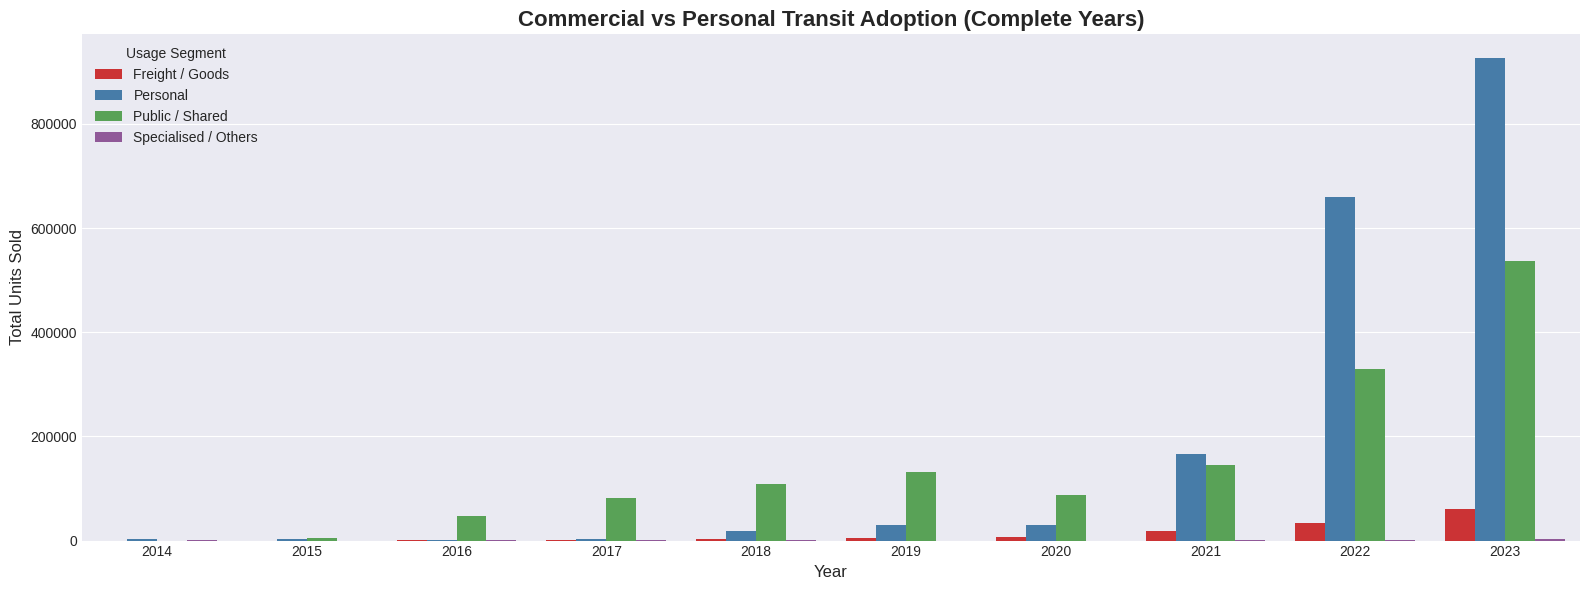

In [76]:
# 8: Usage Segment Breakdown
# Group data by Year and the engineered Usage_Segment feature
usage_year = df.groupby(['Year', 'Usage_Segment'], observed=False)['EV_Sales_Quantity'].sum().reset_index()
usage_year_complete = usage_year[usage_year['Year'] < 2024]

# Render Grouped Bar Chart
plt.figure(figsize=(16, 6))
sns.barplot(
    data=usage_year_complete,
    x='Year',
    y='EV_Sales_Quantity',
    hue='Usage_Segment',
    palette='Set1'
)

plt.title('Commercial vs Personal Transit Adoption (Complete Years)')
plt.ylabel('Total Units Sold')
plt.xlabel('Year')
plt.legend(title='Usage Segment', loc='upper left')
plt.tight_layout()
plt.show()

### Part 3: State-Level Penetration & Geographic Hotspots
This theme identifies the geographic hubs driving national EV volumes, exposes emerging or underserved regional markets, and highlights structural differences in state-level adoption (e.g., Pareto concentration and vehicle category preferences).

In [77]:
# State-level master aggregation
state_summary = df.groupby('State', observed=False, as_index=False)['EV_Sales_Quantity'].sum()
state_summary = state_summary.sort_values(by='EV_Sales_Quantity', ascending=False).reset_index(drop=True)

# Calculate Market Shares
state_summary['Market_Share_%'] = (state_summary['EV_Sales_Quantity'] / state_summary['EV_Sales_Quantity'].sum()) * 100
state_summary['Cumulative_Share_%'] = state_summary['Market_Share_%'].cumsum()

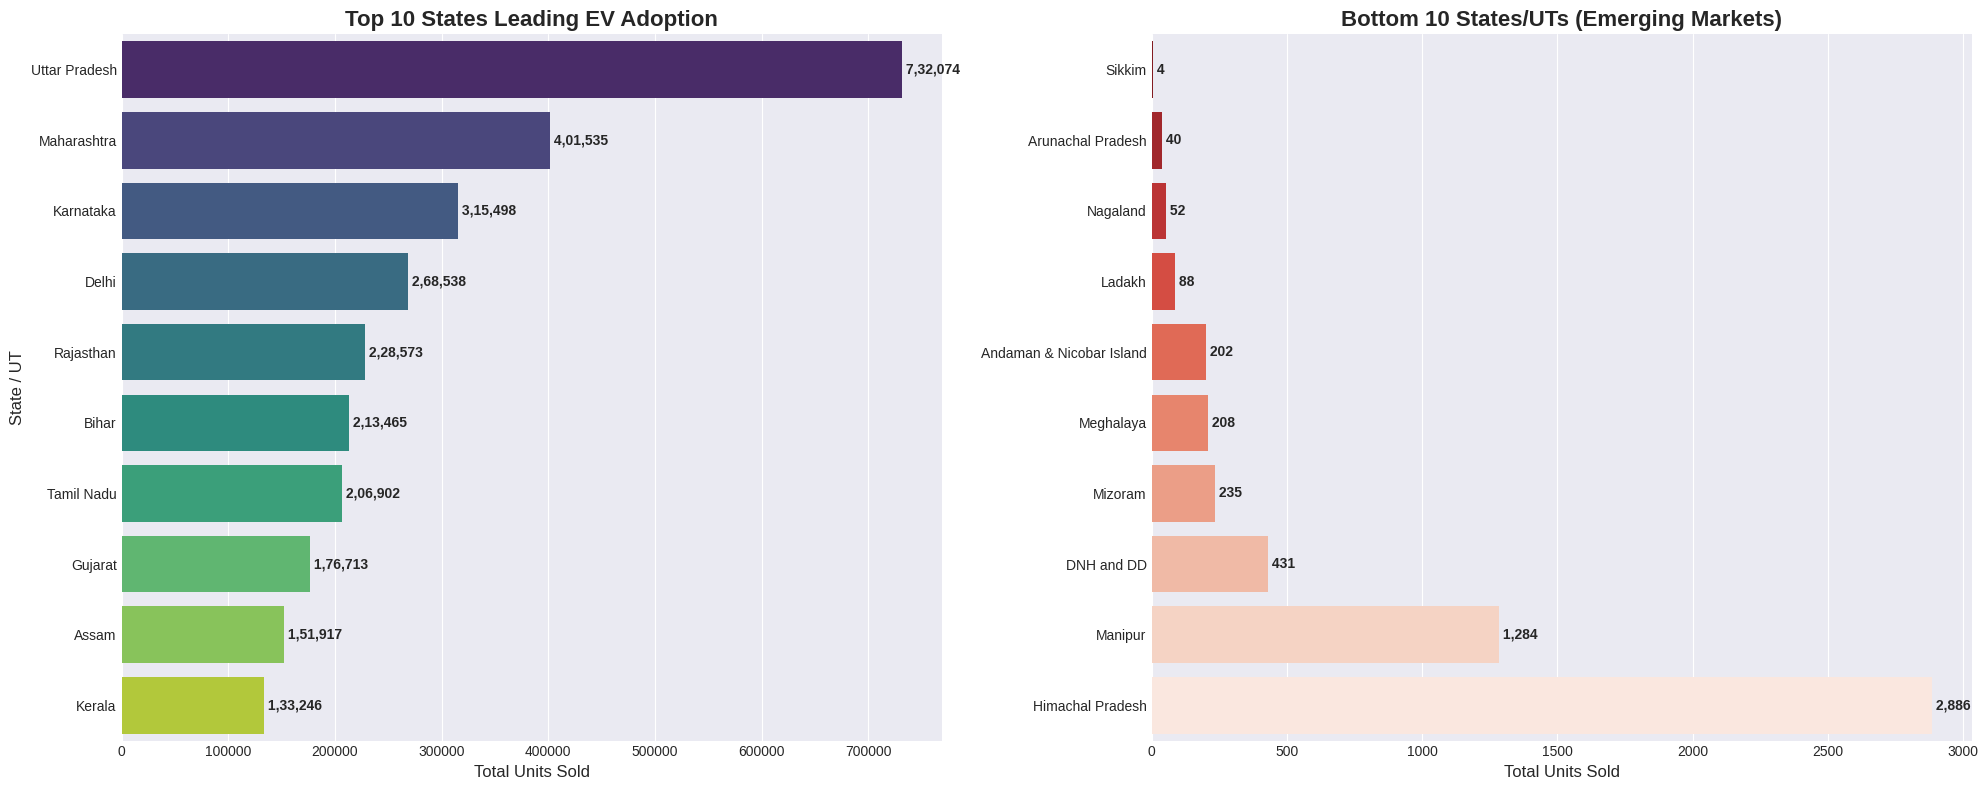

In [78]:
top10_states = state_summary.head(10).copy()
top10_states['State'] = top10_states['State'].astype(str)

bottom10_states = state_summary.tail(10).copy().sort_values(by='EV_Sales_Quantity', ascending=True)
bottom10_states['State'] = bottom10_states['State'].astype(str)

# Render 1x2 Subplot Grid
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# 9: Top 10 States
sns.barplot(x=top10_states.values[:, 1], y=top10_states['State'], palette='viridis', ax=ax[0])
ax[0].set_title('Top 10 States Leading EV Adoption')
ax[0].set_xlabel('Total Units Sold')
ax[0].set_ylabel('State / UT')

for index, value in enumerate(top10_states.values[:, 1]):
    ax[0].text(value, index, f' {format_num(value)}', va='center', fontweight='bold')

# 10: Bottom 10 States
sns.barplot(x=bottom10_states.values[:, 1], y=bottom10_states['State'], palette='Reds_r', ax=ax[1])
ax[1].set_title('Bottom 10 States/UTs (Emerging Markets)')
ax[1].set_xlabel('Total Units Sold')
ax[1].set_ylabel('')

for index, value in enumerate(bottom10_states.values[:, 1]):
    ax[1].text(value, index, f' {format_num(value)}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

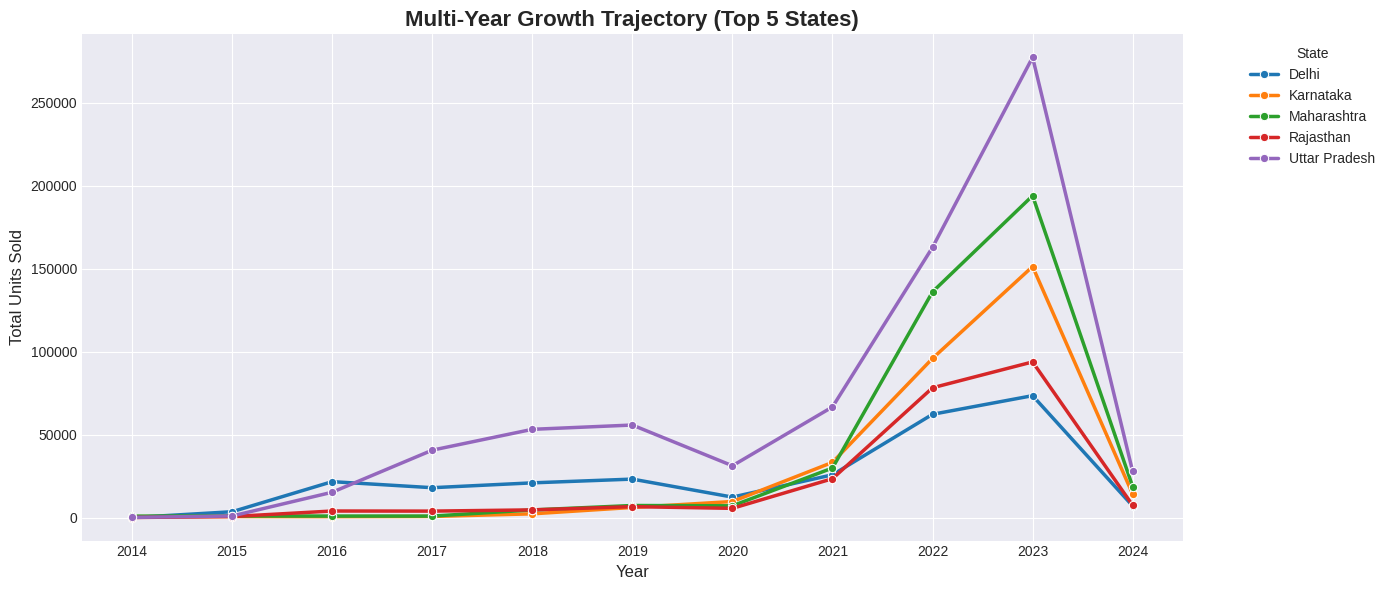

In [79]:
# 11: Multi-Year Trajectory for Top 5 States
top5_names = state_summary.head(5)['State'].tolist()

# Filter data
top5_df = df[df['State'].isin(top5_names)].copy()

# Convert 'State' to string BEFORE grouping to drop the unobserved 29 states
top5_df['State'] = top5_df['State'].astype(str)

# Group by Year and State
top5_yearly = top5_df.groupby(['Year', 'State'], as_index=False)['EV_Sales_Quantity'].sum()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=top5_yearly,
    x='Year',
    y='EV_Sales_Quantity',
    hue='State',
    marker='o',
    linewidth=2.5,
    palette='tab10'
)

plt.title('Multi-Year Growth Trajectory (Top 5 States)')
plt.ylabel('Total Units Sold')
plt.xlabel('Year')
plt.xticks(top5_yearly['Year'].unique())

# Clean legend formatting
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

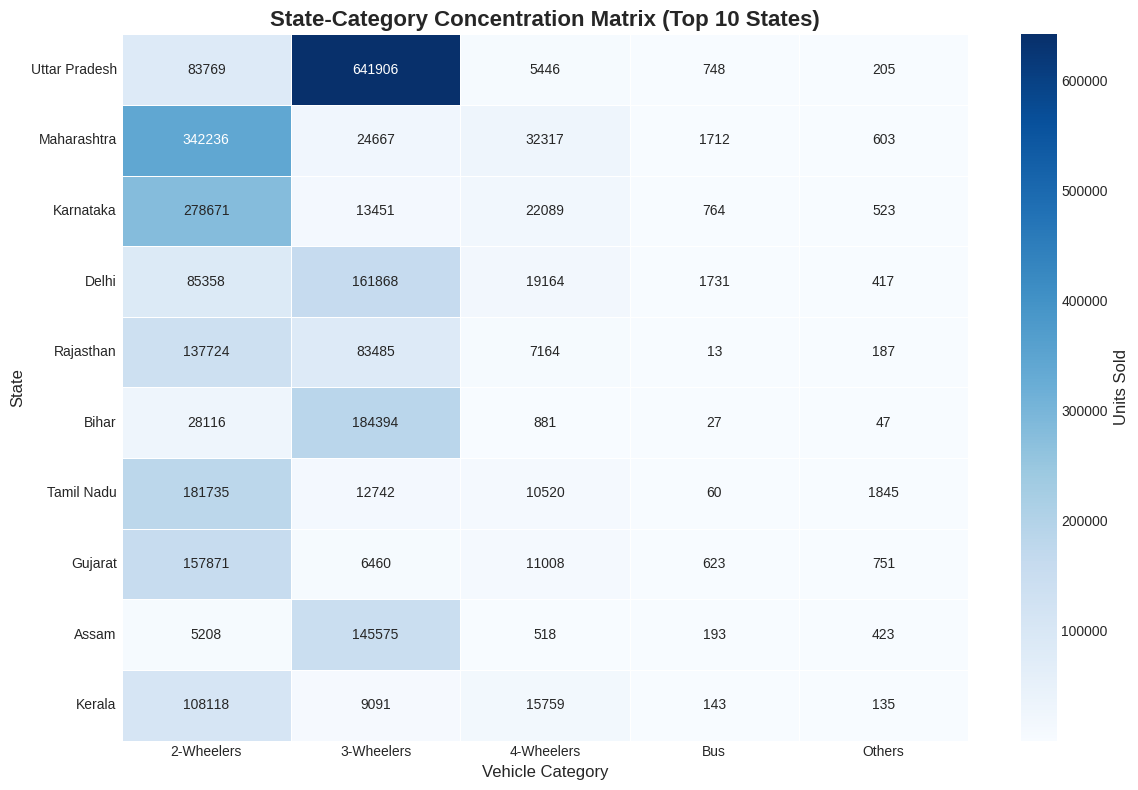

In [80]:
# 12: State-Category Concentration Matrix
top10_names = state_summary.head(10)['State'].tolist()
top10_df = df[df['State'].isin(top10_names)].copy()

# Build the pivot matrix
state_cat_matrix = top10_df.pivot_table(
    index='State',
    columns='Vehicle_Category',
    values='EV_Sales_Quantity',
    aggfunc='sum',
    observed=False
).loc[top10_names]

state_cat_matrix.index = state_cat_matrix.index.astype(str)

plt.figure(figsize=(12, 8))
sns.heatmap(state_cat_matrix, cmap='Blues', annot=True, fmt='.0f', linewidths=0.5, cbar_kws={'label': 'Units Sold'})
plt.title('State-Category Concentration Matrix (Top 10 States)')
plt.ylabel('State')
plt.xlabel('Vehicle Category')
plt.tight_layout()
plt.show()

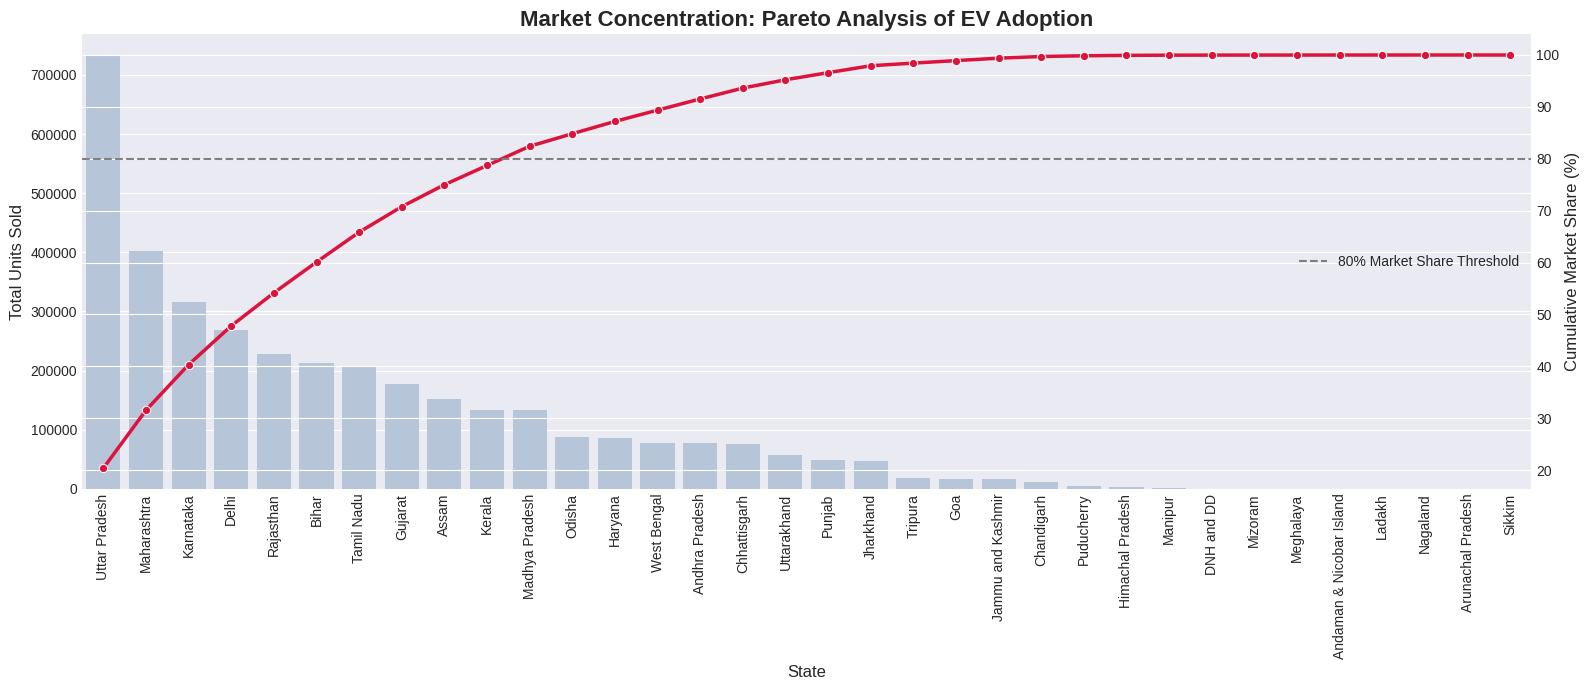

In [81]:
# 13: Market Concentration (Pareto Analysis)
fig, ax1 = plt.subplots(figsize=(16, 7))

# Ensure string types for clean plotting
state_summary['State_Str'] = state_summary['State'].astype(str)

# Primary Axis: Bar chart of total volumes
sns.barplot(
    data=state_summary,
    x='State_Str',
    y='EV_Sales_Quantity',
    color='lightsteelblue',
    ax=ax1
)
ax1.set_ylabel('Total Units Sold')
ax1.set_xlabel('State')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# Secondary Axis: Cumulative percentage line
ax2 = ax1.twinx()
sns.lineplot(
    data=state_summary,
    x='State_Str',
    y='Cumulative_Share_%',
    color='crimson',
    marker='o',
    linewidth=2.5,
    ax=ax2
)
ax2.set_ylabel('Cumulative Market Share (%)')

# Add 80% threshold line (Pareto Principle)
ax2.axhline(80, color='grey', linestyle='--', label='80% Market Share Threshold')
ax2.legend(loc='center right')

plt.title('Market Concentration: Pareto Analysis of EV Adoption')
plt.xlim(-0.5, len(state_summary) - 0.5) # Clean up x-axis margins
plt.tight_layout()
plt.show()

### Part 4: Deep-Dive Sectoral Comparisons
Investigating micro-mobility preferences (2-Wheelers vs 3-Wheelers), state-level commitment to public transit electrification (Buses), and the statistical distribution/volatility of monthly sales across regional hubs.

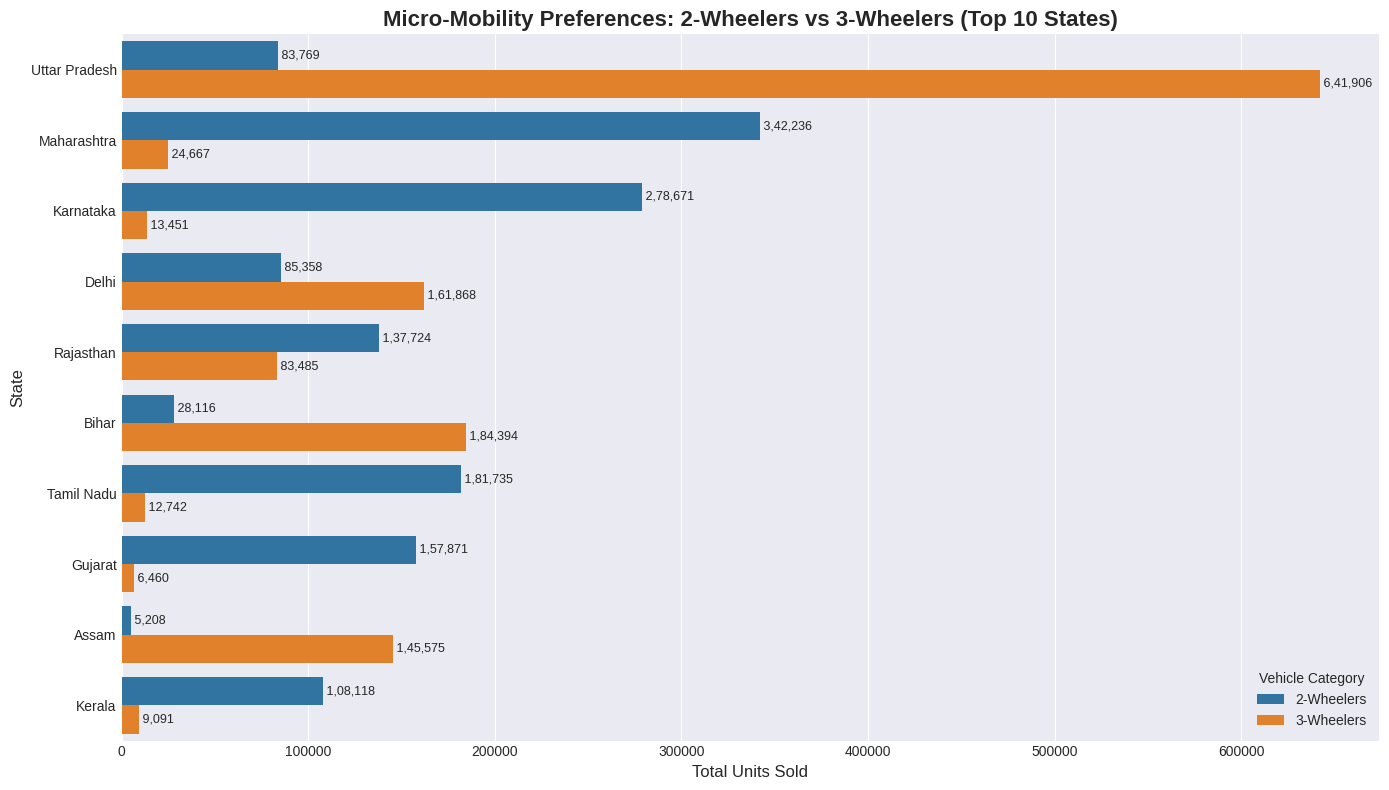

In [82]:
# 14: 2-Wheeler vs 3-Wheeler Dominance
# Isolate 2W and 3W data for the Top 10 states
top10_names = state_summary.head(10)['State'].tolist()
micro_df = df[df['State'].isin(top10_names) & df['Vehicle_Category'].isin(['2-Wheelers', '3-Wheelers'])].copy()

# Fix string representations
micro_df['State'] = micro_df['State'].astype(str)
micro_df['Vehicle_Category'] = micro_df['Vehicle_Category'].astype(str)

# Group and aggregate
micro_summary = micro_df.groupby(['State', 'Vehicle_Category'], as_index=False)['EV_Sales_Quantity'].sum()

# Render Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 8))

sns.barplot(
    data=micro_summary,
    x='EV_Sales_Quantity',
    y='State',
    hue='Vehicle_Category',
    order=top10_names, # Maintain the Top 10 ranking order
    palette=['#1f77b4', '#ff7f0e'],
    ax=ax
)

plt.title('Micro-Mobility Preferences: 2-Wheelers vs 3-Wheelers (Top 10 States)')
plt.xlabel('Total Units Sold')
plt.ylabel('State')

# Annotate each bar cleanly
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Ensure we don't annotate empty bars
        ax.text(width, p.get_y() + p.get_height() / 2, f' {format_num(width)}', va='center', fontsize=9)

plt.legend(title='Vehicle Category', loc='lower right')
plt.tight_layout()
plt.show()

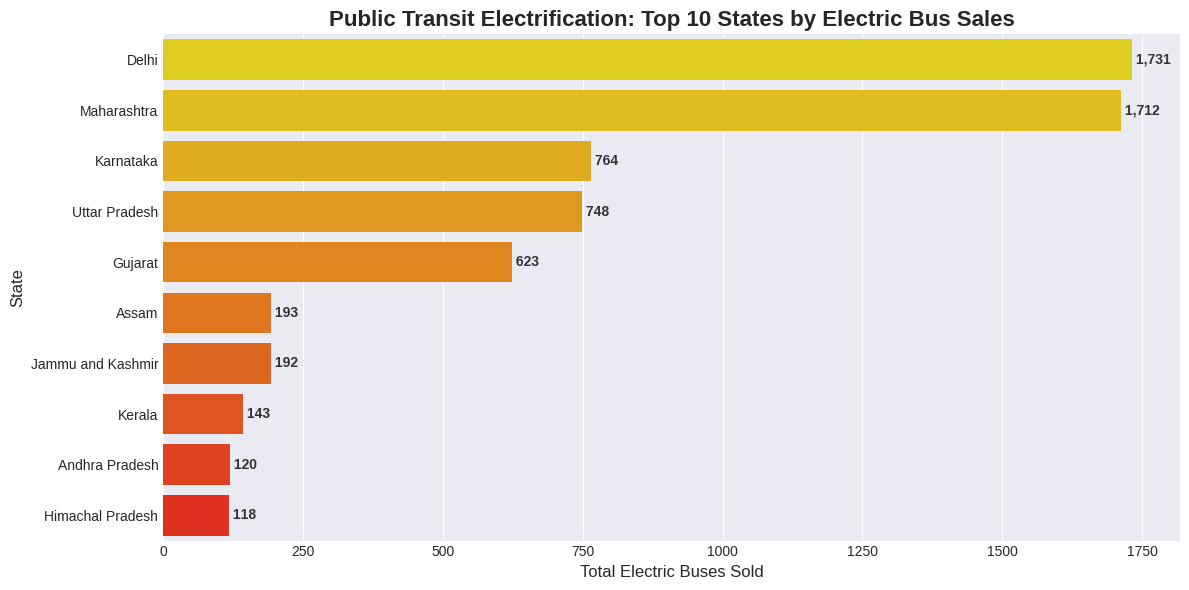

In [83]:
# 15: Public Transit (Bus) Electrification
# Isolate Bus category data globally
bus_df = df[df['Vehicle_Category'] == 'Bus'].copy()
bus_df['State'] = bus_df['State'].astype(str)

# Aggregate and rank top 10 states for Electric Buses
bus_top10 = bus_df.groupby('State', as_index=False)['EV_Sales_Quantity'].sum()
bus_top10 = bus_top10.sort_values(by='EV_Sales_Quantity', ascending=False).head(10).reset_index(drop=True)

# Render Horizontal Bar Chart
plt.figure(figsize=(12, 6))
ax2 = sns.barplot(
    data=bus_top10,
    x='EV_Sales_Quantity',
    y='State',
    palette='autumn_r'
)

plt.title('Public Transit Electrification: Top 10 States by Electric Bus Sales')
plt.xlabel('Total Electric Buses Sold')
plt.ylabel('State')

# Add Indian-formatted annotations
for index, value in enumerate(bus_top10['EV_Sales_Quantity']):
    ax2.text(value, index, f' {format_num(value)}', va='center', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

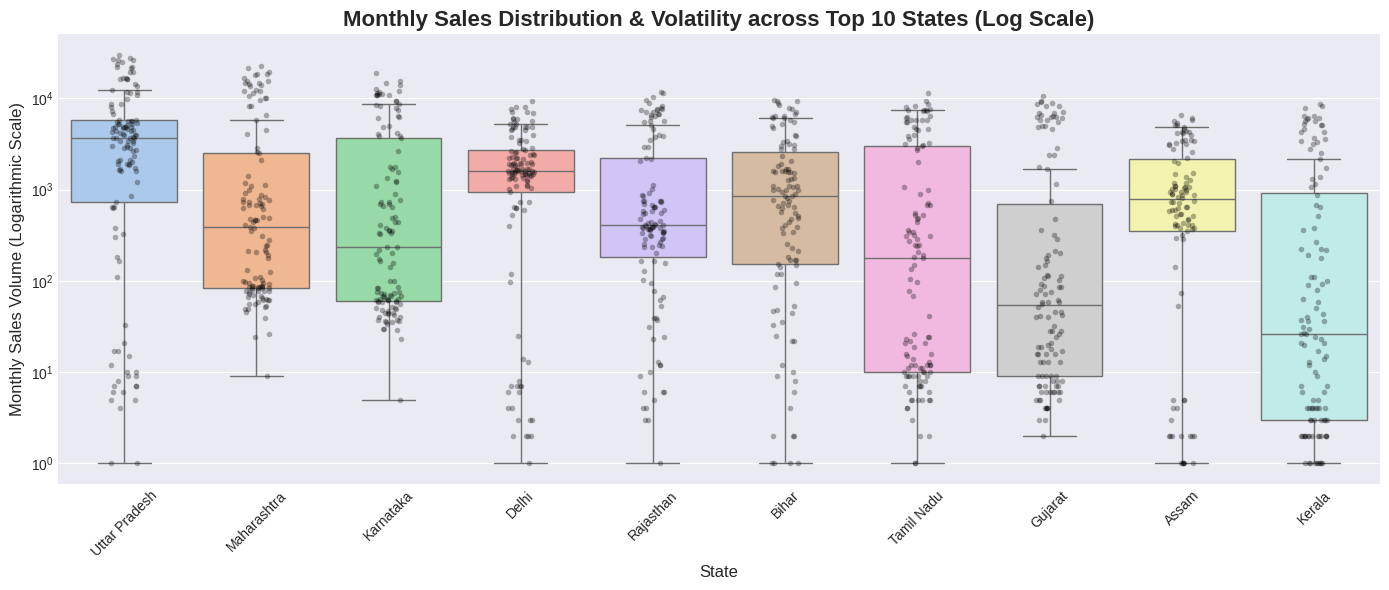

In [84]:
# 16: Sales Distribution & Variance (Log-Scaled Box Plot)
# Prepare monthly aggregated data per state for the Top 10 states
monthly_state = df[df['State'].isin(top10_names)].copy()
monthly_state['State'] = monthly_state['State'].astype(str)
monthly_state_agg = monthly_state.groupby(['State', 'Date'], as_index=False)['EV_Sales_Quantity'].sum()

# Filter out zero-sales months to cleanly plot on a logarithmic scale
monthly_state_agg = monthly_state_agg[monthly_state_agg['EV_Sales_Quantity'] > 0]

# Render Log-Scaled Box Plot with Strip Plot overlay
plt.figure(figsize=(14, 6))

# Main box plot for interquartile ranges and medians
sns.boxplot(
    data=monthly_state_agg,
    x='State',
    y='EV_Sales_Quantity',
    order=top10_names,
    palette='pastel',
    showfliers=False # Hide default outliers to avoid overlapping with strip plot
)

# Strip plot overlay to show exact historical monthly distributions
sns.stripplot(
    data=monthly_state_agg,
    x='State',
    y='EV_Sales_Quantity',
    order=top10_names,
    color='black',
    alpha=0.3,
    size=4,
    jitter=True
)

# Set Y-axis to Logarithmic Scale to handle massive variance
plt.yscale('log')
plt.title('Monthly Sales Distribution & Volatility across Top 10 States (Log Scale)')
plt.xlabel('State')
plt.ylabel('Monthly Sales Volume (Logarithmic Scale)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Part 5: Advanced Segment Dynamics & Fleet Logistics
This visual suite dissects the granular sub-segments of the market: tracking the rise of commercial freight, comparing low-speed E-Rickshaws against regular electric autos, analysing 4-wheeler fleet vs. personal adoption, and mapping quarterly purchasing cycles.

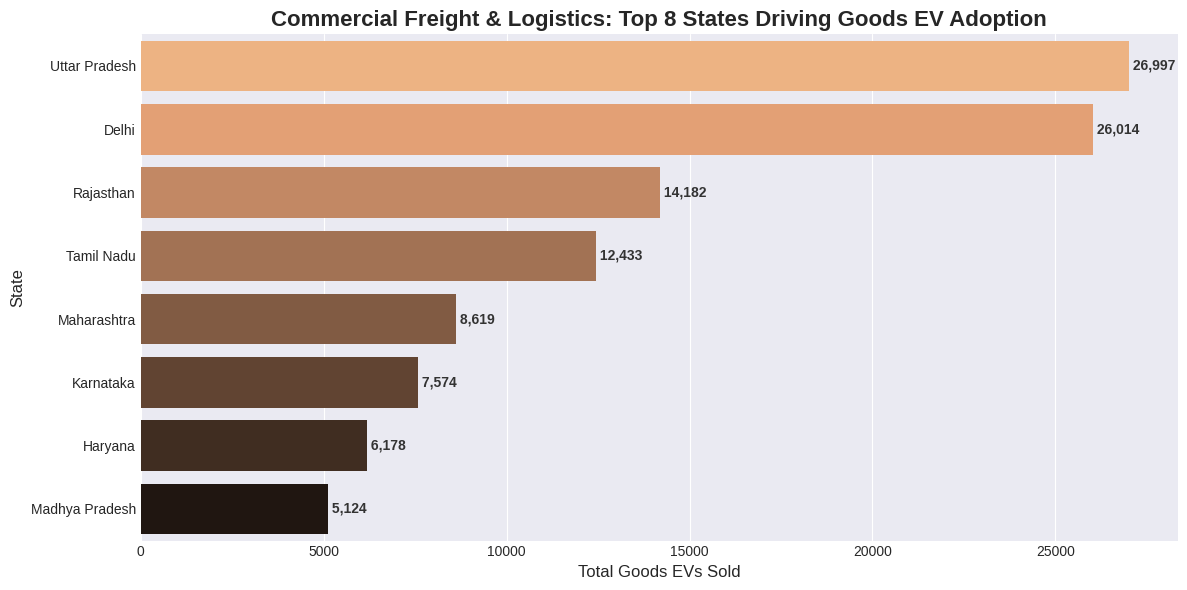

In [85]:
# 17: Commercial Freight Adoption (Top States)
# Isolate Commercial Goods/Freight vehicles
goods_df = df[df['Vehicle_Type'].str.contains('Goods', na=False, case=False)].copy()

# Rank the Top 8 states for Commercial Freight EVs
goods_top = goods_df.groupby('State', observed=False)['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(8)
goods_top.index = goods_top.index.astype(str)

plt.figure(figsize=(12, 6))
ax4 = sns.barplot(x=goods_top.values, y=goods_top.index, palette='copper_r')

plt.title('Commercial Freight & Logistics: Top 8 States Driving Goods EV Adoption')
plt.xlabel('Total Goods EVs Sold')
plt.ylabel('State')

for index, value in enumerate(goods_top.values):
    ax4.text(value, index, f' {format_num(value)}', va='center', fontweight='bold', color='#333')

plt.tight_layout()
plt.show()

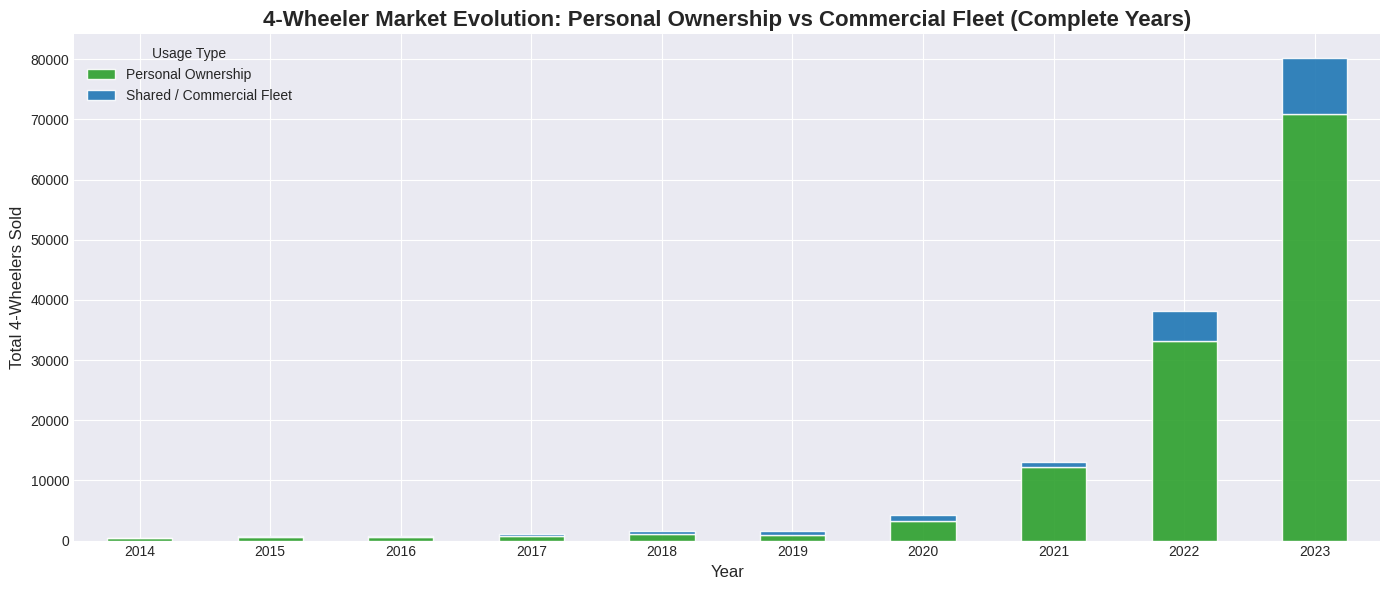

In [86]:
# 18: 4-Wheeler Evolution: Personal vs Fleet
# Isolate 4-Wheeler data and classify by Personal vs Fleet usage
four_w = df[df['Vehicle_Category'] == '4-Wheelers'].copy()
four_w['Usage_Type'] = four_w['Vehicle_Type'].apply(
    lambda x: 'Shared / Commercial Fleet' if 'Shared' in str(x) else 'Personal Ownership'
)

# Group by Year and pivot
four_w_usage = four_w.groupby(['Year', 'Usage_Type'], observed=False)['EV_Sales_Quantity'].sum().unstack().fillna(0)
four_w_usage = four_w_usage[four_w_usage.index < 2024] # Drop incomplete 2024 data

# Render Stacked Bar Chart
four_w_usage.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#2ca02c', '#1f77b4'], alpha=0.9, edgecolor='white')

plt.title('4-Wheeler Market Evolution: Personal Ownership vs Commercial Fleet (Complete Years)')
plt.xlabel('Year')
plt.ylabel('Total 4-Wheelers Sold')
plt.legend(title='Usage Type', loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

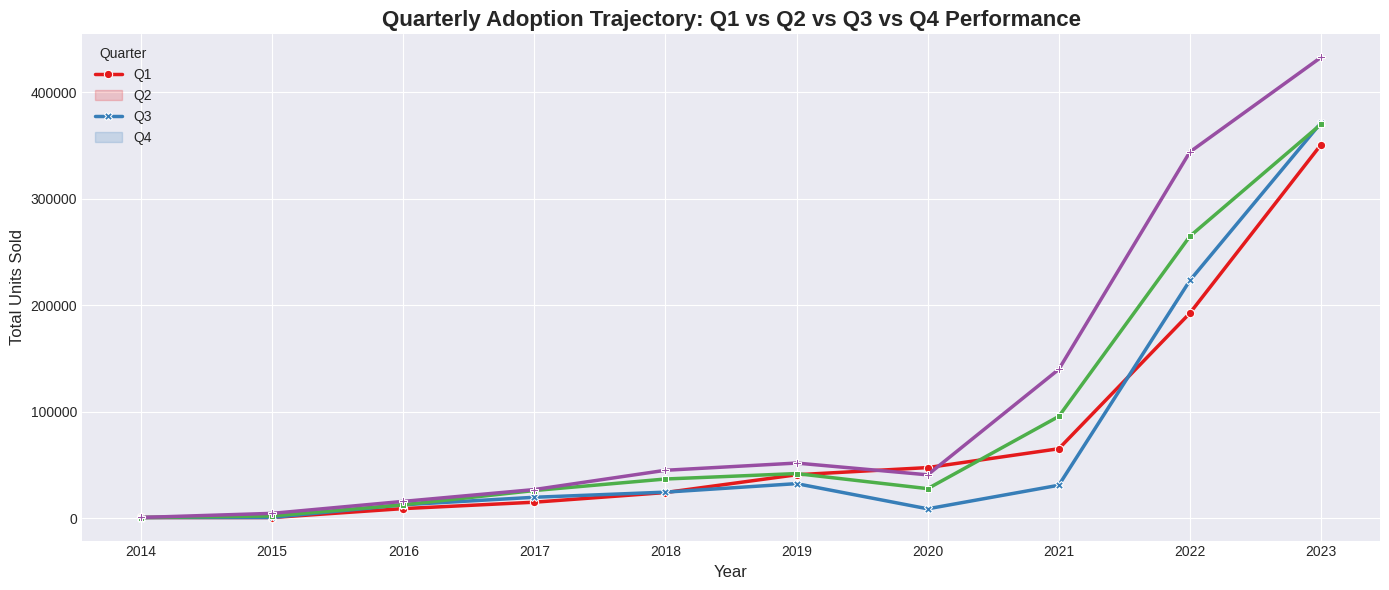

In [87]:
# 19: Quarterly Adoption Trajectory
# Create a pivot table for Quarterly performance across years
quarterly = df.pivot_table(
    index='Year',
    columns='Quarter',
    values='EV_Sales_Quantity',
    aggfunc='sum',
    observed=False
)
quarterly_clean = quarterly.dropna() # Drop 2024 as it doesn't have a full set of quarters

# Render Multi-line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(data=quarterly_clean, markers=True, dashes=False, linewidth=2.5, palette='Set1')

plt.title('Quarterly Adoption Trajectory: Q1 vs Q2 vs Q3 vs Q4 Performance')
plt.xlabel('Year')
plt.ylabel('Total Units Sold')
plt.legend(title='Quarter', labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.xticks(quarterly_clean.index)
plt.tight_layout()
plt.show()

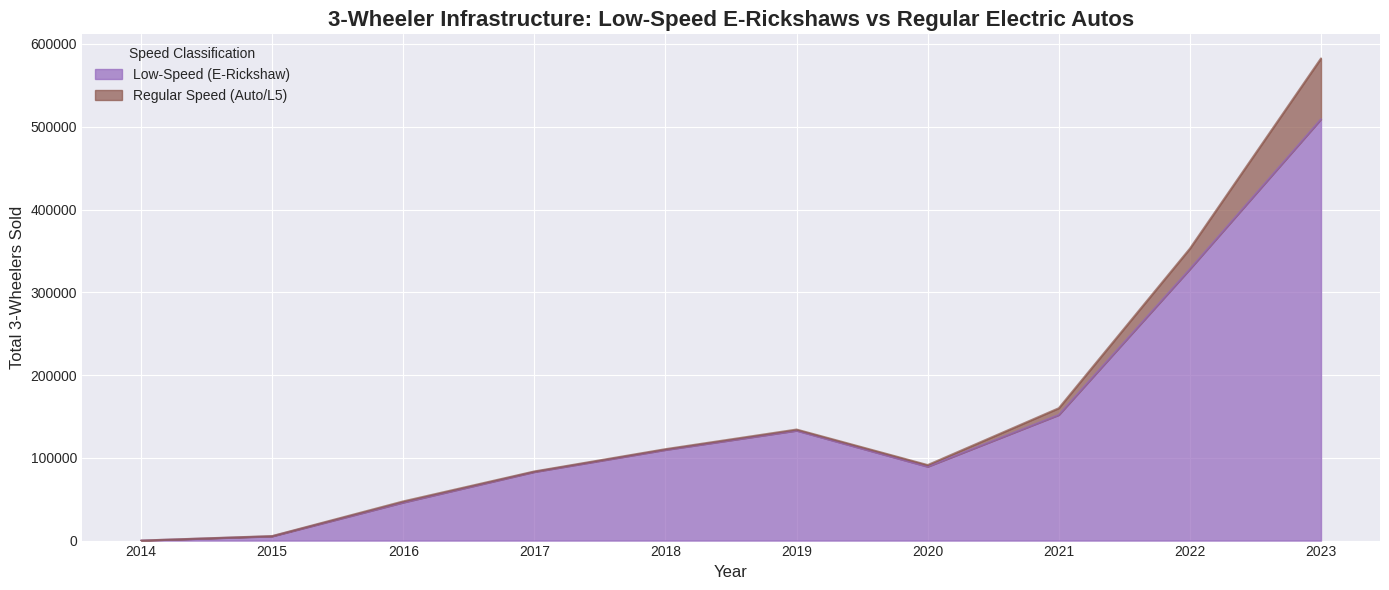

In [88]:
# 20: 3-Wheeler Split (Low-Speed vs Regular)
# Isolate 3-Wheeler data and classify by Speed capacity
three_w = df[df['Vehicle_Category'] == '3-Wheelers'].copy()
three_w['Speed_Class'] = three_w['Vehicle_Type'].apply(
    lambda x: 'Low-Speed (E-Rickshaw)' if 'LowSpeed' in str(x) else 'Regular Speed (Auto/L5)'
)

# Group by Year and pivot
three_w_speed = three_w.groupby(['Year', 'Speed_Class'], observed=False)['EV_Sales_Quantity'].sum().unstack().fillna(0)
three_w_speed = three_w_speed[three_w_speed.index < 2024] # Drop incomplete 2024

# Render Area Chart
three_w_speed.plot(kind='area', stacked=True, figsize=(14, 6), color=['#9467bd', '#8c564b'], alpha=0.7)

plt.title('3-Wheeler Infrastructure: Low-Speed E-Rickshaws vs Regular Electric Autos')
plt.xlabel('Year')
plt.ylabel('Total 3-Wheelers Sold')
plt.legend(title='Speed Classification', loc='upper left')
plt.xticks(three_w_speed.index)
plt.tight_layout()
plt.show()

# Strategic Business Insights & Summary

## Executive Summary
This exploratory data analysis tracked the adoption of Electric Vehicles across India from 2014 to 2024, evaluating over 96,000 regional registration records across multiple vehicle classes.

---

## Key Analytical Findings

* **Micro-Mobility Dominance:** Two-wheelers and three-wheelers comprise over **95% of total cumulative EV sales**. High-speed passenger cars (4-Wheelers) and public buses remain in early-stage adoption, primarily constrained by acquisition costs and charging infrastructure.
* **Geographic Pareto Concentration:** The market follows a strict Pareto distribution where the **top 10 states generate ~80% of all national volume**. Uttar Pradesh, Maharashtra, Karnataka, and Delhi serve as the primary growth engines.
* **Regional Market Dichotomy:**
  * **Northern, Central, Eastern & North-Eastern Hubs (e.g., Uttar Pradesh, Bihar, Assam, Madhya Pradesh):** Growth is overwhelmingly driven by commercial three-wheelers (low-speed E-Rickshaws) for affordable last-mile public transit.
  * **Southern & Western Hubs (e.g., Maharashtra, Karnataka, Rajasthan, Gujarat, Telangana):** Adoption is almost exclusively led by personal two-wheeler scooters and motorcycles.
* **Commercial Fleet & Freight Expansion:** Commercial cargo three-wheelers and delivery fleets have seen accelerated uptake post-2021, driven by lower total cost of ownership (TCO) in urban logistics.
* **Seasonality & Purchasing Cycles:** Quarterly demand consistently peaks during **Q4 (October–December)**, aligning with festive purchasing cycles and annual commercial fleet renewals.

---

## Strategic Recommendations

1. **Targeted Charging Infrastructure:** Prioritise fast-charging corridors within the top 5 states (Maharashtra, Karnataka, Delhi, Uttar Pradesh & Rajasthan) to support growing 2W and 4W inter-city transit.
2. **Rural & Tier-2/3 Strategy:** Incentivise regular-speed (L5) cargo three-wheelers in high E-Rickshaw regions (e.g., Uttar Pradesh & Bihar) to upgrade last-mile logistics capability.
3. **Public Transit Expansion:** Accelerate state-level bus fleet tenders outside Delhi and Maharashtra to address mass transit decarbonisation.